## GPR on WeatherBench Data - z500
Apply GP regression baseline (using exact GP to train on monthly data)

In [1]:
# Check GPU
!nvidia-smi

Sun Mar 16 00:34:08 2025       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.12             Driver Version: 535.104.12   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA A100 80GB PCIe          Off | 00000000:1B:00.0 Off |                    0 |
| N/A   83C    P0             269W / 300W |  10861MiB / 81920MiB |     52%      Default |
|                                         |                      |             Disabled |
+-----------------------------------------+----------------------+--

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import time
import gc
from tqdm.notebook import tqdm

import torch
from torch.utils.data import TensorDataset, DataLoader
import gpytorch

from GPyTorch.GPRs.model import ExactGP
from GPyTorch.GPRs.utils import latlon_to_cartesian, cartesian_to_latlon
from GPyTorch.GPRs.process_data import create_data

torch.set_default_dtype(torch.float64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Data Processing

Loading the data

In [ ]:
z500 = xr.open_mfdataset('data/5.625deg/geopotential_500/*.nc', combine='by_coords')
z500_train = z500.sel(time=slice('2017', '2017')).isel(lat=slice(24, 32), lon=slice(16, 32))['z']
z500_test = z500.sel(time=slice('2018', '2018.1.7')).isel(lat=slice(24, 32), lon=slice(16, 32))['z'] 

In [3]:
data_mean = z500_train.mean().load()
data_std = z500_train.std().load()

# Normalize datasets
data_train = (z500_train - data_mean) / data_std
data_test = (z500_test - data_mean) / data_std

## Defining the Kernel

We use a separable kernel in space and time:
$$K(x,y,z,t) = K_{\text{space}}(x,y,z) \times K_{\text{time}}(t),$$
where $K_{\text{space}}(x,y,z) = \sum_n K_{n\text{, Matern}}(x,y,z)$ and $K_{\text{time}}(t) = \sum_n K_{n\text{, Periodic}}(t)$.

In [7]:
def latlon_to_cartesian(lat, lon, device=device):
    """ Converting (lat., lon.) to cartesian coordinates on a unit sphere
        Note: WeatherBench data is defined on a constant altitude """

    lat, lon = np.deg2rad(lat), np.deg2rad(lon)

    x = np.cos(lat)[:, None] * np.cos(lon)[None, :]
    y = np.cos(lat)[:, None] * np.sin(lon)[None, :]
    z = np.sin(lat)[:, None] * np.ones_like(lon)[None, :]

    xyz = np.stack([x, y, z], axis=-1)  # Out: (nlat, nlon, 3)
    return torch.tensor(xyz).to(device)

def cartesian_to_latlon(xyz):

    x = xyz[..., 0]
    y = xyz[..., 1]
    z = xyz[..., 2]

    lat = np.arcsin(z) 
    lon = np.arctan2(y, x)  
    lat_deg = np.degrees(lat)
    lon_deg = np.degrees(lon)
    lon_deg = (lon_deg + 360) % 360
    latlon = np.stack([lat_deg, lon_deg], axis=-1)
    return latlon

Subsampling the datasets due to memory issues

In [8]:
def create_data(data_train, data_test, lead_time_h, space_subsample=1, time_subsample=1, device=device, train=True):
    """Preparing input and output data. X should be the coordinate input into the kernel, 
    while Y should be the forecast target (shifted lead time)."""

    if lead_time_h == 0:
        X = data_train.isel(time=slice(0, None, time_subsample),
                        lat=slice(0, None, space_subsample),
                        lon=slice(0, None, space_subsample))
        
    else:
        X = data_train.isel(time=slice(0, -lead_time_h, time_subsample),
                            lat=slice(0, None, space_subsample),
                            lon=slice(0, None, space_subsample))
        Y = data_train.isel(time=slice(lead_time_h, None, time_subsample),
                    lat=slice(0, None, space_subsample),
                    lon=slice(0, None, space_subsample)) 

    # Preparing the input coords (should have shape (ntime, nlat, nlon, 4) if we have no subsampling)
    X_time = (X.time - data_train.time[0]).values / np.timedelta64(1, 'h')
    X_time = torch.tensor(X_time).to(device)
    t_steps = X_time.shape[0]

    latitudes = X.lat.values 
    longitudes = X.lon.values 
    cartesian_coords = latlon_to_cartesian(latitudes, longitudes, device)
    nlat, nlon, _ = cartesian_coords.shape

    if train:
        print("Processing Training Dataset")
        # Combine spatial and temporal data
        training_coords = torch.empty((t_steps, nlat, nlon, 4)).to(device)
        # Fill in the spatial part first
        training_coords[..., :3] = cartesian_coords.unsqueeze(0).expand(t_steps, -1, -1, -1)
        # The final element is time
        training_coords[..., 3] = X_time.view(t_steps, 1, 1).expand(t_steps, nlat, nlon)
        X_size = training_coords.element_size() * training_coords.nelement() / (1024**2)
        print(f"Combined coords info --> Shape: {training_coords.shape}, Mem: {X_size:.2f} MB")

        if lead_time_h == 0:
            Y = torch.tensor(X.values).view(-1).to(device)
        else:
            # Flatten to shape (N,)
            Y = torch.tensor(Y.values).view(-1).to(device)
            Y_size = Y.element_size() * Y.nelement() / (1024**2)
            print(f"Target info --> Shape: {Y.shape}, Mem: {Y_size:.2f} MB")

        return training_coords, Y
    
    else:
        # Testing Data
        if lead_time_h == 0:
            X_test = data_test.isel(time=slice(0, None, time_subsample),
                            lat=slice(0, None, space_subsample),
                            lon=slice(0, None, space_subsample))
        else:
            X_test = data_test.isel(time=slice(0, -lead_time_h, time_subsample),
                                lat=slice(0, None, space_subsample),
                                lon=slice(0, None, space_subsample))
            Y_test = data_test.isel(time=slice(lead_time_h, None, time_subsample),
                        lat=slice(0, None, space_subsample),
                        lon=slice(0, None, space_subsample))
        X_test_time = (X_test.time - data_train.time[0]).values / np.timedelta64(1, 'h')
        X_test_time = torch.tensor(X_test_time).to(device)
        test_t_steps = X_test_time.shape[0]

        print("Processing Test Dataset")
        # Combine spatial and temporal data
        testing_coords = torch.empty((test_t_steps, nlat, nlon, 4)).to(device)
        # Fill in the spatial part first
        testing_coords[..., :3] = cartesian_coords.unsqueeze(0).expand(test_t_steps, -1, -1, -1)
        # The final element is time
        testing_coords[..., 3] = X_test_time.view(test_t_steps, 1, 1).expand(test_t_steps, nlat, nlon)
        X_size = testing_coords.element_size() * testing_coords.nelement() / (1024**2)
        print(f"Combined coords info --> Shape: {testing_coords.shape}, Mem: {X_size:.2f} MB")

        if lead_time_h == 0:
            Y_test = torch.tensor(X_test.values).view(-1).to(device)
        else:
            # Flatten to shape (N,)
            Y_test = torch.tensor(Y_test.values).view(-1).to(device)
            Y_size = Y_test.element_size() * Y_test.nelement() / (1024**2)
            print(f"Target info --> Shape: {Y_test.shape}, Mem: {Y_size:.2f} MB")

        return testing_coords, Y_test, latitudes, longitudes

## Defining the Kernel

We work on the 2d-hypersphere, modeling the spatial kernel with Geometric_Kernel and time kernel with periodic kernel. 

In [9]:
# Define the GP regression kernel, separable in space and time
matern_spatial_1 = gpytorch.kernels.MaternKernel(nu=1.5, active_dims=[0,1,2]).to(device)
matern_spatial_1.lengthscale = torch.tensor(0.08).to(device)
#matern_spatial_1.register_prior("lengthscale_prior", gpytorch.priors.NormalPrior(0.5, 0.1), "lengthscale")

matern_spatial_2 = gpytorch.kernels.MaternKernel(nu=1.5, active_dims=[0,1,2]).to(device)
matern_spatial_2.lengthscale = torch.tensor(0.5).to(device)
#matern_spatial_2.register_prior("lengthscale_prior", gpytorch.priors.NormalPrior(1.5, 0.3), "lengthscale")

matern_spatial_3 = gpytorch.kernels.MaternKernel(nu=1.5, active_dims=[0,1,2]).to(device)
matern_spatial_3.lengthscale = torch.tensor(1).to(device)
#matern_spatial_3.register_prior("lengthscale_prior", gpytorch.priors.NormalPrior(3.0, 0.6), "lengthscale")

# spatial_kernel = gpytorch.kernels.ScaleKernel(matern_spatial_1+matern_spatial_2+matern_spatial_3).to(device)
spatial_kernel = matern_spatial_1+matern_spatial_2+matern_spatial_3

In [10]:
# For temporal kernel
# time_kernel1 = gpytorch.kernels.PeriodicKernel(active_dims=[3]).to(device) # Daily    
# time_kernel1.period_length = torch.tensor(24).to(device)
# time_kernel2 = gpytorch.kernels.PeriodicKernel(active_dims=[3]).to(device) # Three days
# time_kernel2.period_length = torch.tensor(24*3).to(device)
# time_kernel3 = gpytorch.kernels.PeriodicKernel(active_dims=[3]).to(device) # Weekly
# time_kernel3.period_length = torch.tensor(24*7).to(device)

#time_kernel1.register_prior("period_length_prior", gpytorch.priors.NormalPrior(24, 3), "period_length")
#time_kernel2.register_prior("period_length_prior", gpytorch.priors.NormalPrior(24*3, 9), "period_length")
#time_kernel3.register_prior("period_length_prior", gpytorch.priors.NormalPrior(24*7, 21), "period_length")
# time_kernel = time_kernel1 + time_kernel2 + time_kernel3

# Define the GP regression kernel, separable in space and time
matern_time_1 = gpytorch.kernels.MaternKernel(nu=1.5, active_dims=[3]).to(device)
matern_time_1.lengthscale = torch.tensor(40).to(device)
#matern_time_2 = gpytorch.kernels.MaternKernel(nu=1.5, active_dims=[3]).to(device)
#matern_time_2.lengthscale = torch.tensor(24*7).to(device)
time_kernel1 = gpytorch.kernels.PeriodicKernel(active_dims=[3]).to(device) 
time_kernel1.period_length = torch.tensor(24).to(device)
time_kernel2 = gpytorch.kernels.PeriodicKernel(active_dims=[3]).to(device) 
time_kernel2.period_length = torch.tensor(24*5).to(device)
time_kernel = matern_time_1 + time_kernel1 + time_kernel2 

# kernel = spatial_kernel * time_kernel
kernel = gpytorch.kernels.ScaleKernel(spatial_kernel * time_kernel).to(device)

class GPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(GPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean() 
        self.covar_module = kernel

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

## Training and Evaluation

In [13]:
def train_gp(lead_time_h, data_train, data_test, space_subsample=1, time_subsample=1, frac=0.01, epochs=6000, save_model=False, device=device):
    """
    Train a Gaussian Process model using GPyTorch. Can add subsampling the data for efficiency.
    """
    
    # Prepare training data
    X_train, Y_train = create_data(data_train, data_test, lead_time_h, space_subsample=space_subsample, 
                                                  time_subsample=time_subsample, device=device)
    # X_train = X_train.view(-1, 4)

    # Random Sampling (should set space and time subsampling be 1 if using random sampling)
    N = X_train.shape[0] * X_train.shape[1] * X_train.shape[2] 
    n_frac = int(frac * N) # Fraction of points to be chosen
    X_train = X_train.view(-1, 4)
    indices = torch.randperm(X_train.size(0))[:n_frac]
    X_train = X_train[indices] 
    Y_train = Y_train[indices]

    likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device)
    #likelihood.noise = torch.tensor(1e-4).to(device)  
    #likelihood.noise_covar.raw_noise.requires_grad_(False) 
    model = GPModel(X_train, Y_train, likelihood).to(device)
    
    # Train model
    model.train()
    likelihood.train()

    # Optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01) 
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.99)

    # Loss fn
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    # Training loop
    print("Starting Exact GP regression training on a single month:")
    # Reset the peak memory statistics before training
    torch.cuda.reset_peak_memory_stats(device)
    start_time = time.time()

    hyperparams_track = []
    with tqdm(total=epochs, desc="Training Progress", unit="epoch") as pbar:
        for i in range(epochs):
            optimizer.zero_grad()
            output = model(X_train)
            loss_val = -mll(output, Y_train)
            loss_val.backward()
            optimizer.step() 
            scheduler.step()
            pbar.set_postfix(loss=f"{loss_val.item():.3f}")
            pbar.update(1)

            # spatial_kernel = model.covar_module.kernels[0]
            # spatial1 = spatial_kernel.base_kernel.kernels[0]
            # spatial2 = spatial_kernel.base_kernel.kernels[1]
            # spatial3 = spatial_kernel.base_kernel.kernels[2]
            # time_sum_kernel = model.covar_module.kernels[1]
            # periodic1 = time_sum_kernel.kernels[0]
            # periodic2 = time_sum_kernel.kernels[1]
            # periodic3 = time_sum_kernel.kernels[2]

            # hyperparams_track.append({
            #     "loss": loss_val.item(),
            #     "mean": model.mean_module.constant.item(),
            #     "noise": model.likelihood.noise.item(),
            #     "spatial_1_lengthscale": spatial1.lengthscale.item(),
            #     "spatial_2_lengthscale": spatial2.lengthscale.item(),
            #     "spatial_3_lengthscale": spatial3.lengthscale.item(),
            #     "spatial_outputscale": spatial_kernel.outputscale.item(),
            #     "time_lengthscale_daily": periodic1.lengthscale.item(),
            #     "time_period_daily": periodic1.period_length.item(),
            #     "time_lengthscale_three_days": periodic2.lengthscale.item(),
            #     "time_period_three_days": periodic2.period_length.item(),
            #     "time_lengthscale_weekly": periodic3.lengthscale.item() ,
            #     "time_period_weekly": periodic3.period_length.item(),
            # })

            spatial_kernel = model.covar_module.base_kernel.kernels[0]
            temporal_kernel = model.covar_module.base_kernel.kernels[1]

            hyperparams_track.append({
                "loss": loss_val.item(),
                "mean": model.mean_module.constant.item(),
                "noise": likelihood.noise.item(),
                "outputscale": model.covar_module.outputscale.item(),
                "spatial_1_lengthscale": spatial_kernel.kernels[0].lengthscale.item(),
                "spatial_2_lengthscale": spatial_kernel.kernels[1].lengthscale.item(),
                "spatial_3_lengthscale": spatial_kernel.kernels[2].lengthscale.item(),
                "matern_time_lengthscale_daily": temporal_kernel.kernels[0].lengthscale.item(),
                # "matern_time_lengthscale_weekly": temporal_kernel.kernels[1].lengthscale.item(),
                "time_lengthscale_daily": temporal_kernel.kernels[1].lengthscale.item(),
                "time_period_daily": temporal_kernel.kernels[1].period_length.item(),
                "time_lengthscale_weekly": temporal_kernel.kernels[2].lengthscale.item(),
                "time_period_weekly": temporal_kernel.kernels[2].period_length.item(),
            })
            

    current_allocated = torch.cuda.memory_allocated(device)
    max_allocated = torch.cuda.max_memory_allocated(device)
    print(f"Current GPU memory allocated: {current_allocated / (1024**2):.2f} MB")
    print(f"Peak GPU memory allocated: {max_allocated / (1024**2):.2f} MB")

    end_time = time.time()
    print("Training completed")
    time_elapsed = end_time - start_time
    print(f"Training time: {time_elapsed:.2f}s")

    # Save model
    if save_model:
        torch.save(model.state_dict(), "STGP-weather-forecasting/saved_models/gp_model.pth")
        torch.save(likelihood.state_dict(), "STGP-weather-forecasting/saved_models/gp_likelihood.pth")
        print("Saved model")

    return model, likelihood, hyperparams_track, X_train, Y_train

In [14]:
lead_time = 0 # 3-day forecasting
space_subsample = 1 # Set 1 if using random subsampling
time_subsample = 6 
frac = 0.05 # Fraction of points to be picked from the full training set
# Train GP model
model, likelihood, hyperparams_track, X_train, Y_train = train_gp(lead_time, data_train, data_test, space_subsample, time_subsample, frac=frac)

Processing Training Dataset
Combined coords info --> Shape: torch.Size([124, 32, 64, 4]), Mem: 7.75 MB
Starting Exact GP regression training on a single month:


Training Progress:   0%|          | 0/6000 [00:00<?, ?epoch/s]

Current GPU memory allocated: 1251.14 MB
Peak GPU memory allocated: 28313.61 MB
Training completed
Training time: 2473.46s


In [25]:
space_subsample = 1 # Set 1 if using random subsampling
time_subsample = 6 

In [ ]:
# Can save before test (due to mem)
#torch.save(model.state_dict(), "STGP-weather-forecasting/saved_models/model_state.pth")
#torch.save(likelihood.state_dict(), "STGP-weather-forecasting/saved_models/likelihood_state.pth")
#torch.save(hyperparams_track, "STGP-weather-forecasting/saved_models/hyperparams_track.pth")
#torch.save(X_train, "STGP-weather-forecasting/saved_models/X_train.pth")
#torch.save(Y_train, "STGP-weather-forecasting/saved_models/Y_train.pth")

In [11]:
hyperparams_track = torch.load("STGP-weather-forecasting/saved_models/hyperparams_track.pth")
X_train = torch.load("STGP-weather-forecasting/saved_models/X_train.pth")
Y_train = torch.load("STGP-weather-forecasting/saved_models/Y_train.pth", weights_only=False)
Y_train = torch.tensor(Y_train).to(device)
likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device)
model = GPModel(X_train, Y_train, likelihood).to(device)

model.load_state_dict(torch.load("STGP-weather-forecasting/saved_models/model_state.pth"))
likelihood.load_state_dict(torch.load("STGP-weather-forecasting/saved_models/likelihood_state.pth"))

<All keys matched successfully>

In [12]:
X_test, Y_test, lat, lon = create_data(data_train, data_test, 0, space_subsample=1, 
                                                time_subsample=8, device=device, train=False)
X_test = X_test.view(-1,4)
nlat = len(lat)
nlon = len(lon)

#N = X_test.shape[0] * X_test.shape[1] * X_test.shape[2] 
#n_frac = int(frac * N) # Fraction of points to be chosen
#X_test = X_test.view(-1, 4)
#indices = torch.randperm(X_test.size(0))[:n_frac]
#X_test = X_test[indices] 
#Y_test = Y_test[indices]

# Make Predictions
model.eval()
likelihood.eval()
with torch.no_grad():
    pred_dist = model(X_test)
    Y_pred = pred_dist.mean
    Y_std = pred_dist.stddev  
    mse = torch.mean((Y_pred - Y_test)**2)
    rmse = torch.sqrt(mse)
    print("MSE: ", mse.item())
    print("RMSE: ", rmse.item())

    Y_pred_actual = (Y_pred.detach().cpu().numpy() * data_std.values + data_mean.values).reshape(-1,nlat,nlon)
    Y_test_actual = (Y_test.detach().cpu().numpy() * data_std.values + data_mean.values).reshape(-1,nlat,nlon)
    err = Y_pred_actual - Y_test_actual
    weights_lat = np.cos(np.deg2rad(lat))
    weights_lat /= weights_lat.mean()
    wrmse = np.sqrt((err**2 * weights_lat[None, :, None]).mean())
    print("Weighted RMSE: ", wrmse)

Y_pred = Y_pred.detach().cpu().numpy()  
Y_test = Y_test.detach().cpu().numpy()  
Y_std = Y_std.detach().cpu().numpy()

Processing Test Dataset
Combined coords info --> Shape: torch.Size([21, 32, 64, 4]), Mem: 1.31 MB


/home/syw24/miniforge3/envs/hartree/lib/python3.12/site-packages/linear_operator/utils/linear_cg.py:338: NumericalWarning: CG terminated in 1000 iterations with average residual norm 0.054516264695978464 which is larger than the tolerance of 0.01 specified by linear_operator.settings.cg_tolerance. If performance is affected, consider raising the maximum number of CG iterations by running code in a linear_operator.settings.max_cg_iterations(value) context.
  warnings.warn(


MSE:  0.07982158073662296
RMSE:  0.28252713274413654
Weighted RMSE:  839.8594664378853


## Performance Plots 

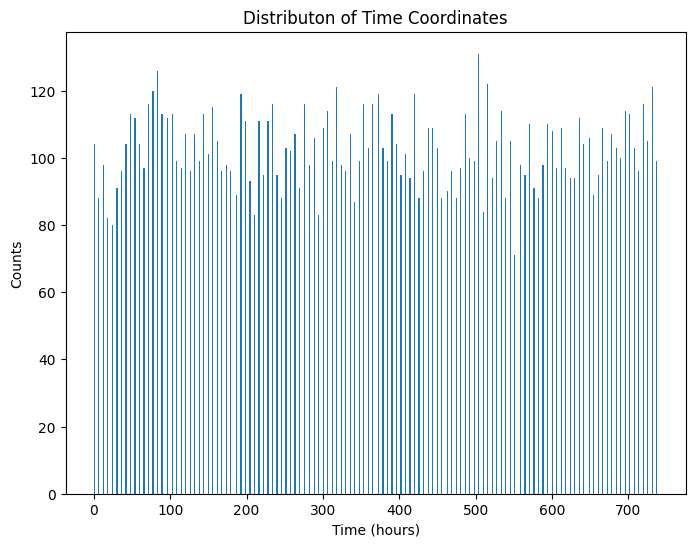

In [13]:
rand_coords = X_train[:,:3].detach().cpu().numpy()
rand_time = X_train[:,3].detach().cpu().numpy()

plt.figure(figsize=(8,6))
plt.hist(rand_time, bins=500)
plt.xlabel('Time (hours)')
plt.ylabel('Counts')
plt.title('Distributon of Time Coordinates')
plt.show()

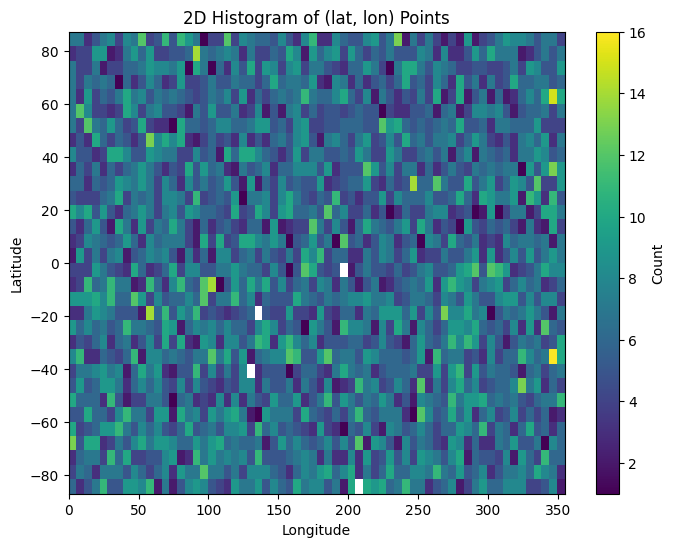

In [14]:
latlon = cartesian_to_latlon(rand_coords)
lat = latlon[:, 0]
lon = latlon[:, 1]

cmap = plt.get_cmap('viridis').copy()
cmap.set_under('white')

plt.figure(figsize=(8,6))
plt.hist2d(lon, lat, bins=[64, 32], cmap=cmap, vmin=1) # highlights bin with 0 counts as red
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('2D Histogram of (lat, lon) Points')
plt.colorbar(label='Count')
plt.show()

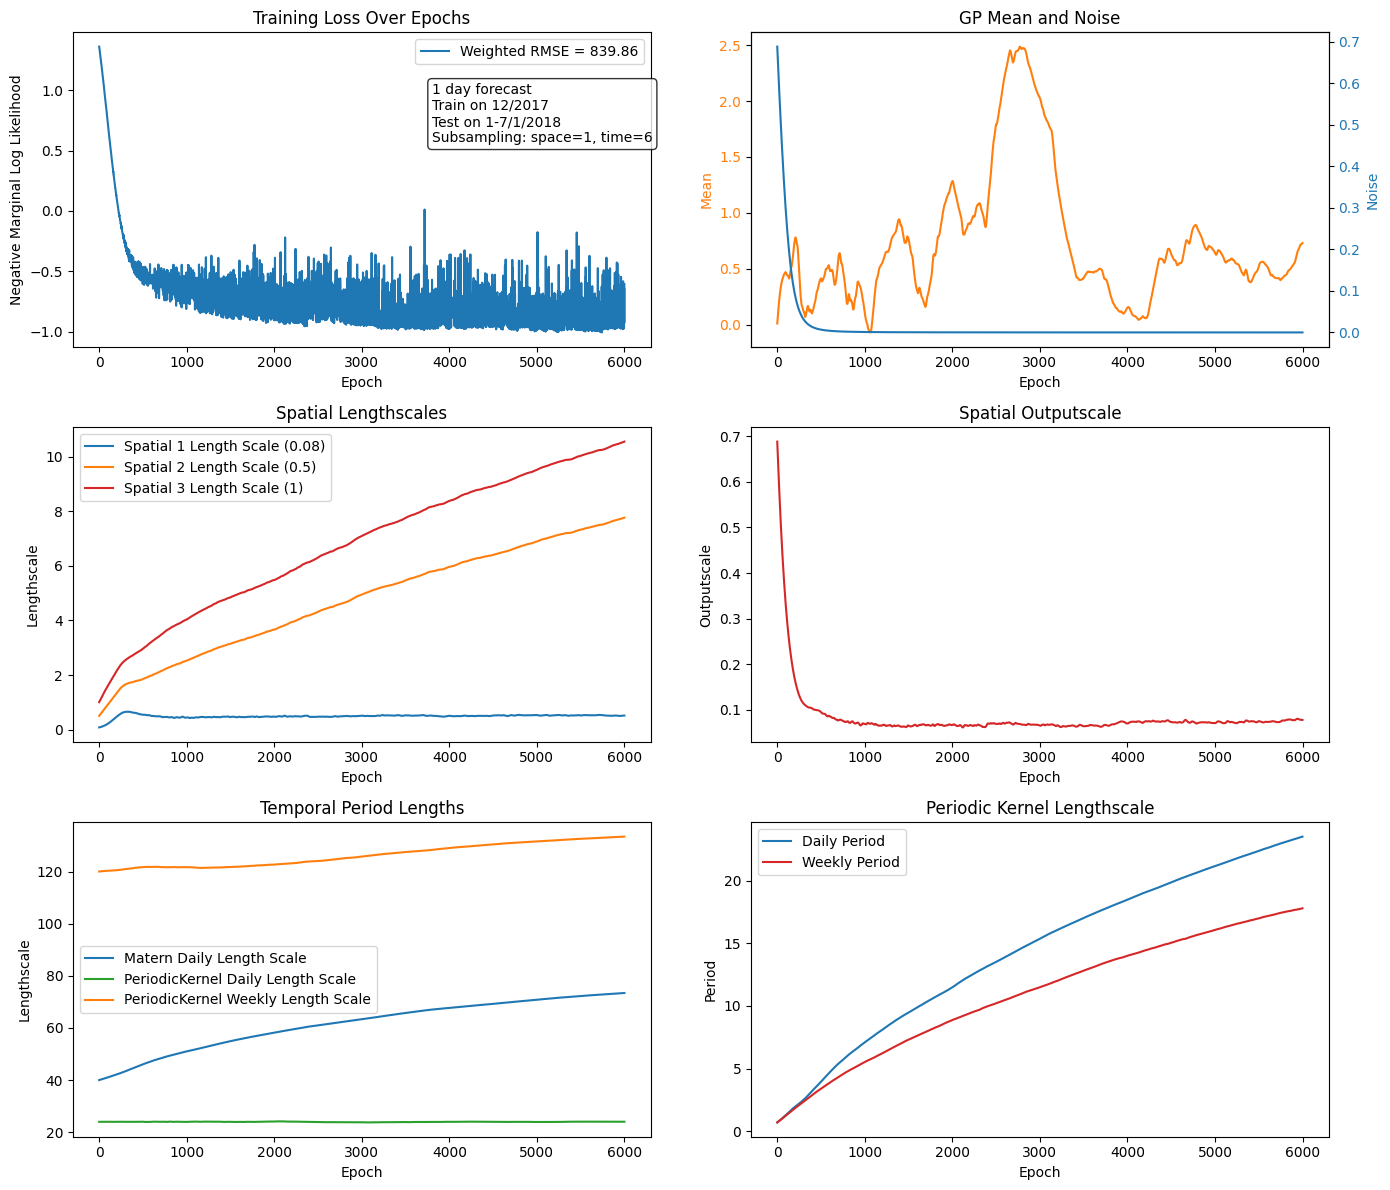

In [26]:
# Convert your tracking list into a DataFrame
df = pd.DataFrame(hyperparams_track)
epochs_range = np.arange(len(df))

# Create a figure with 3 rows and 2 columns of subplots
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(14, 12))

# --- Row 1 ---
# Left: Loss
axs[0, 0].plot(epochs_range, df["loss"], label=f'Weighted RMSE = {wrmse:.2f}', color='tab:blue')
axs[0, 0].set_title("Training Loss Over Epochs")
axs[0, 0].set_xlabel("Epoch")
axs[0, 0].set_ylabel("Negative Marginal Log Likelihood")
axs[0, 0].legend()

axs[0, 0].text(
    0.6215, 0.65, 
    f"1 day forecast\nTrain on 12/2017\nTest on 1-7/1/2018\nSubsampling: space={space_subsample}, time={time_subsample}",
    transform=axs[0, 0].transAxes,  # interpret (x, y) as axes-relative
    fontsize=10,
    bbox=dict(facecolor='white', alpha=0.8, boxstyle='round')
)

# Right: Mean and Noise
axs[0, 1].plot(epochs_range, df["mean"], color='tab:orange', label="Mean")
axs[0, 1].set_title("GP Mean and Noise")
axs[0, 1].set_xlabel("Epoch")
axs[0, 1].set_ylabel("Mean", color='tab:orange')
axs[0, 1].tick_params(axis='y', labelcolor='tab:orange')
ax_noise = axs[0, 1].twinx()
ax_noise.plot(epochs_range, df["noise"], color='tab:blue', label="Noise")
ax_noise.set_ylabel("Noise", color='tab:blue')
ax_noise.tick_params(axis='y', labelcolor='tab:blue')

# --- Row 2 ---
# Left: Spatial lengthscales
axs[1, 0].plot(epochs_range, df["spatial_1_lengthscale"], label='Spatial 1 Length Scale (0.08)', color='tab:blue')
axs[1, 0].plot(epochs_range, df["spatial_2_lengthscale"], label='Spatial 2 Length Scale (0.5)', color='tab:orange')
axs[1, 0].plot(epochs_range, df["spatial_3_lengthscale"], label='Spatial 3 Length Scale (1)' , color='tab:red')
axs[1, 0].set_title("Spatial Lengthscales")
axs[1, 0].set_xlabel("Epoch")
axs[1, 0].set_ylabel("Lengthscale")
axs[1, 0].legend()

# Right: Spatial outputscale
# axs[1, 1].plot(epochs_range, df["spatial_outputscale"], label='Output scale from ScaleKernel', color='tab:red')
axs[1, 1].plot(epochs_range, df["outputscale"], label='Output scale from ScaleKernel', color='tab:red')
axs[1, 1].set_title("Spatial Outputscale")
axs[1, 1].set_xlabel("Epoch")
axs[1, 1].set_ylabel("Outputscale")

# --- Row 3 ---
# Left: Temporal lengthscales
axs[2, 0].plot(epochs_range, df["matern_time_lengthscale_daily"], label='Matern Daily Length Scale', color='tab:blue')
#axs[2, 0].plot(epochs_range, df["matern_time_lengthscale_weekly"], label='Matern Weekly Length Scale', color='tab:red')
axs[2, 0].plot(epochs_range, df["time_period_daily"], label='PeriodicKernel Daily Length Scale', color='tab:green')
axs[2, 0].plot(epochs_range, df["time_period_weekly"], label='PeriodicKernel Weekly Length Scale', color='tab:orange')
axs[2, 0].set_title("Temporal Period Lengths")
axs[2, 0].set_xlabel("Epoch")
axs[2, 0].set_ylabel("Lengthscale")
axs[2, 0].legend()

# Right: Temporal periods
axs[2, 1].plot(epochs_range, df["time_lengthscale_daily"], label='Daily Period', color='tab:blue')
# axs[2, 1].plot(epochs_range, df["time_period_three_days"], label='3-Day Period', color='tab:orange')
axs[2, 1].plot(epochs_range, df["time_lengthscale_weekly"], label='Weekly Period', color='tab:red')
axs[2, 1].set_title("Periodic Kernel Lengthscale")
axs[2, 1].set_xlabel("Epoch")
axs[2, 1].set_ylabel("Period")
axs[2, 1].legend()

plt.tight_layout()
plt.show()

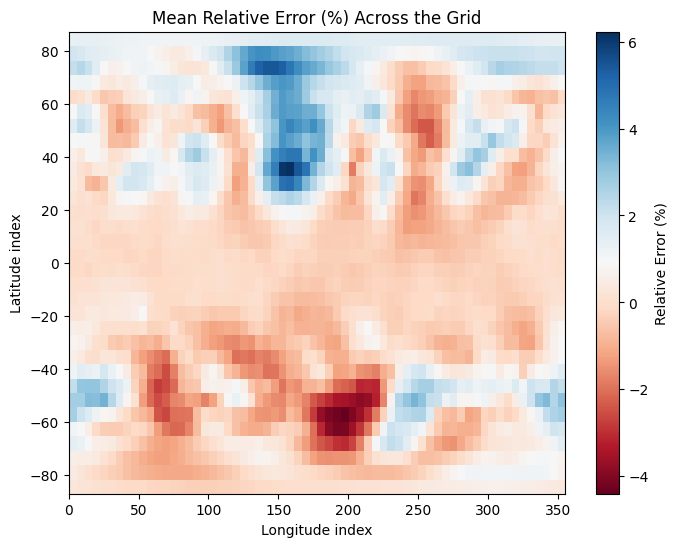

In [16]:
relative_error = (Y_pred_actual - Y_test_actual) / Y_test_actual * 100  # shape (ntime, 7, 13)
relative_error_mean = relative_error.mean(axis=0)  # shape (7, 13)

plt.figure(figsize=(8, 6))
im = plt.imshow(relative_error_mean, cmap='RdBu', aspect='auto',
                extent=[lon.min(), lon.max(), lat.min(), lat.max()],
                origin='lower')
plt.title('Mean Relative Error (%) Across the Grid')
plt.xlabel('Longitude index')
plt.ylabel('Latitude index')
plt.colorbar(im, label='Relative Error (%)')
plt.show()

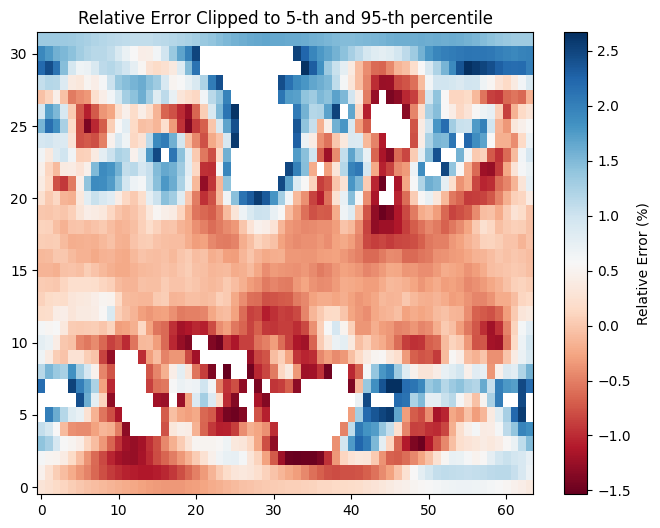

In [17]:
low_q = np.percentile(relative_error_mean, 5)
high_q = np.percentile(relative_error_mean, 95)
masked_error = np.ma.masked_outside(relative_error_mean, low_q, high_q)

plt.figure(figsize=(8, 6))
im = plt.imshow(masked_error, cmap='RdBu', aspect='auto', origin='lower')
plt.colorbar(im, label='Relative Error (%)')
plt.title('Relative Error Clipped to 5-th and 95-th percentile')
plt.show()

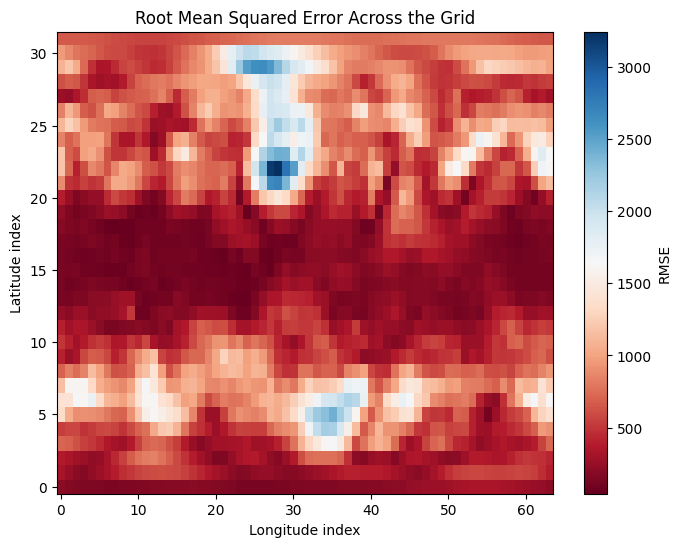

In [18]:
rmse_error = np.sqrt((Y_pred_actual - Y_test_actual)**2)
rmse_error_mean = rmse_error.mean(axis=0)  # shape (7, 13)

plt.figure(figsize=(8, 6))
im = plt.imshow(rmse_error_mean, cmap='RdBu', aspect='auto', origin='lower')
plt.title('Root Mean Squared Error Across the Grid')
plt.xlabel('Longitude index')
plt.ylabel('Latitude index')
plt.colorbar(im, label='RMSE')
plt.show()

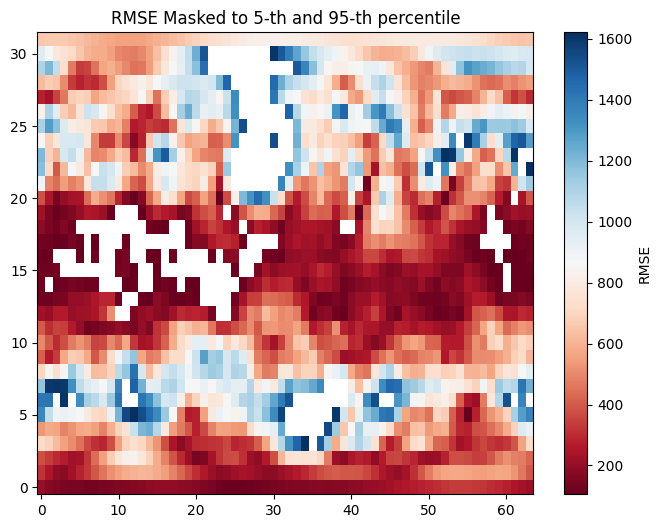

In [19]:
low_q_rmse = np.percentile(rmse_error_mean, 5)
high_q_rmse = np.percentile(rmse_error_mean, 95)
masked_error_rmse = np.ma.masked_outside(rmse_error_mean, low_q_rmse, high_q_rmse)

plt.figure(figsize=(8, 6))
im = plt.imshow(masked_error_rmse, cmap='RdBu', aspect='auto', origin='lower')
plt.colorbar(im, label='RMSE')
plt.title('RMSE Masked to 5-th and 95-th percentile')
plt.show()

In [20]:
max_idx = np.argmax(relative_error_mean)
min_idx = np.argmin(relative_error_mean)
best_idx = np.argmin(np.abs(relative_error_mean))

flat_max_idx = np.unravel_index(max_idx, relative_error_mean.shape)
flat_min_idx = np.unravel_index(min_idx, relative_error_mean.shape)
flat_best_idx = np.unravel_index(best_idx, relative_error_mean.shape)

max_err = relative_error_mean[flat_max_idx[0],flat_max_idx[1]]
min_err = relative_error_mean[flat_min_idx[0],flat_min_idx[1]]
best_err = relative_error_mean[flat_best_idx[0],flat_best_idx[1]]

print(f"Highest relative error: ({int(flat_max_idx[0])},{int(flat_max_idx[1])}), with relative error in percentage: {max_err:.3f}")
print(f"Lowest relative error: ({int(flat_min_idx[0])},{int(flat_min_idx[1])}), with relative error in percentage: {min_err:.3f}")
print(f"Smallest relative error: ({int(flat_best_idx[0])},{int(flat_best_idx[1])}), with relative error in percentage: {best_err:.3f}")

Highest relative error: (22,28), with relative error in percentage: 6.226
Lowest relative error: (5,35), with relative error in percentage: -4.400
Smallest relative error: (10,3), with relative error in percentage: 0.000


In [21]:
# Best and worst location based on rmse
rmse_max_idx = np.argmax(rmse_error_mean)
rmse_min_idx = np.argmin(rmse_error_mean)

flat_rmse_max_idx = np.unravel_index(rmse_max_idx, rmse_error_mean.shape)
flat_rmse_min_idx = np.unravel_index(rmse_min_idx, rmse_error_mean.shape)

rmse_max_err = rmse_error_mean[flat_rmse_max_idx[0],flat_rmse_max_idx[1]]
rmse_min_err = rmse_error_mean[flat_rmse_min_idx[0],flat_rmse_min_idx[1]]

print(f"Highest RMSE: ({int(flat_rmse_max_idx[0])},{int(flat_rmse_max_idx[1])}), with value: {rmse_max_err:.3f}")
print(f"Lowest RMSE: ({int(flat_rmse_min_idx[0])},{int(flat_rmse_min_idx[1])}), with value: {rmse_min_err:.3f}")

Highest RMSE: (22,28), with value: 3243.156
Lowest RMSE: (18,7), with value: 41.540


In [ ]:
"""results = []
spatial_kernel = model.covar_module.kernels[0]
spatial1 = spatial_kernel.base_kernel.kernels[0]
spatial2 = spatial_kernel.base_kernel.kernels[1]
spatial3 = spatial_kernel.base_kernel.kernels[2]
time_sum_kernel = model.covar_module.kernels[1]
periodic1 = time_sum_kernel.kernels[0]
periodic2 = time_sum_kernel.kernels[1]
periodic3 = time_sum_kernel.kernels[2]

results.append({
    "mean": model.mean_module.constant.item(),
    "noise": model.likelihood.noise.item(),
    "spatial_1_lengthscale": spatial1.lengthscale.item(),
    "spatial_2_lengthscale": spatial2.lengthscale.item(),
    "spatial_3_lengthscale": spatial3.lengthscale.item(),
    "spatial_outputscale": spatial_kernel.outputscale.item(),
    "time_lengthscale_daily": periodic1.lengthscale.item(),
    "time_period_daily": periodic1.period_length.item(),
    "time_lengthscale_three_days": periodic2.lengthscale.item(),
    "time_period_three_days": periodic2.period_length.item(),
    "time_lengthscale_weekly": periodic3.lengthscale.item() ,
    "time_period_weekly": periodic3.period_length.item(),
})
results"""

'results = []\nspatial_kernel = model.covar_module.kernels[0]\nspatial1 = spatial_kernel.base_kernel.kernels[0]\nspatial2 = spatial_kernel.base_kernel.kernels[1]\nspatial3 = spatial_kernel.base_kernel.kernels[2]\ntime_sum_kernel = model.covar_module.kernels[1]\nperiodic1 = time_sum_kernel.kernels[0]\nperiodic2 = time_sum_kernel.kernels[1]\nperiodic3 = time_sum_kernel.kernels[2]\n\nresults.append({\n    "mean": model.mean_module.constant.item(),\n    "noise": model.likelihood.noise.item(),\n    "spatial_1_lengthscale": spatial1.lengthscale.item(),\n    "spatial_2_lengthscale": spatial2.lengthscale.item(),\n    "spatial_3_lengthscale": spatial3.lengthscale.item(),\n    "spatial_outputscale": spatial_kernel.outputscale.item(),\n    "time_lengthscale_daily": periodic1.lengthscale.item(),\n    "time_period_daily": periodic1.period_length.item(),\n    "time_lengthscale_three_days": periodic2.lengthscale.item(),\n    "time_period_three_days": periodic2.period_length.item(),\n    "time_lengths

## Observing how the individual point performs

In [22]:
# Reorder the array if using random sampling
sorted_idx = torch.argsort(X_train[:,3])

X_train = X_train[sorted_idx]
Y_train = Y_train[sorted_idx]

In [23]:
model.eval()
likelihood.eval()
# X_train = X_train.view(-1,4)
with torch.no_grad():
    pred_train = model(X_train)
    train_mean = pred_train.mean  
    train_std = pred_train.stddev  

train_mean = train_mean.detach().cpu().numpy()
train_std = train_std.detach().cpu().numpy()
Y_train = Y_train.detach().cpu().numpy()

/home/syw24/miniforge3/envs/hartree/lib/python3.12/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(


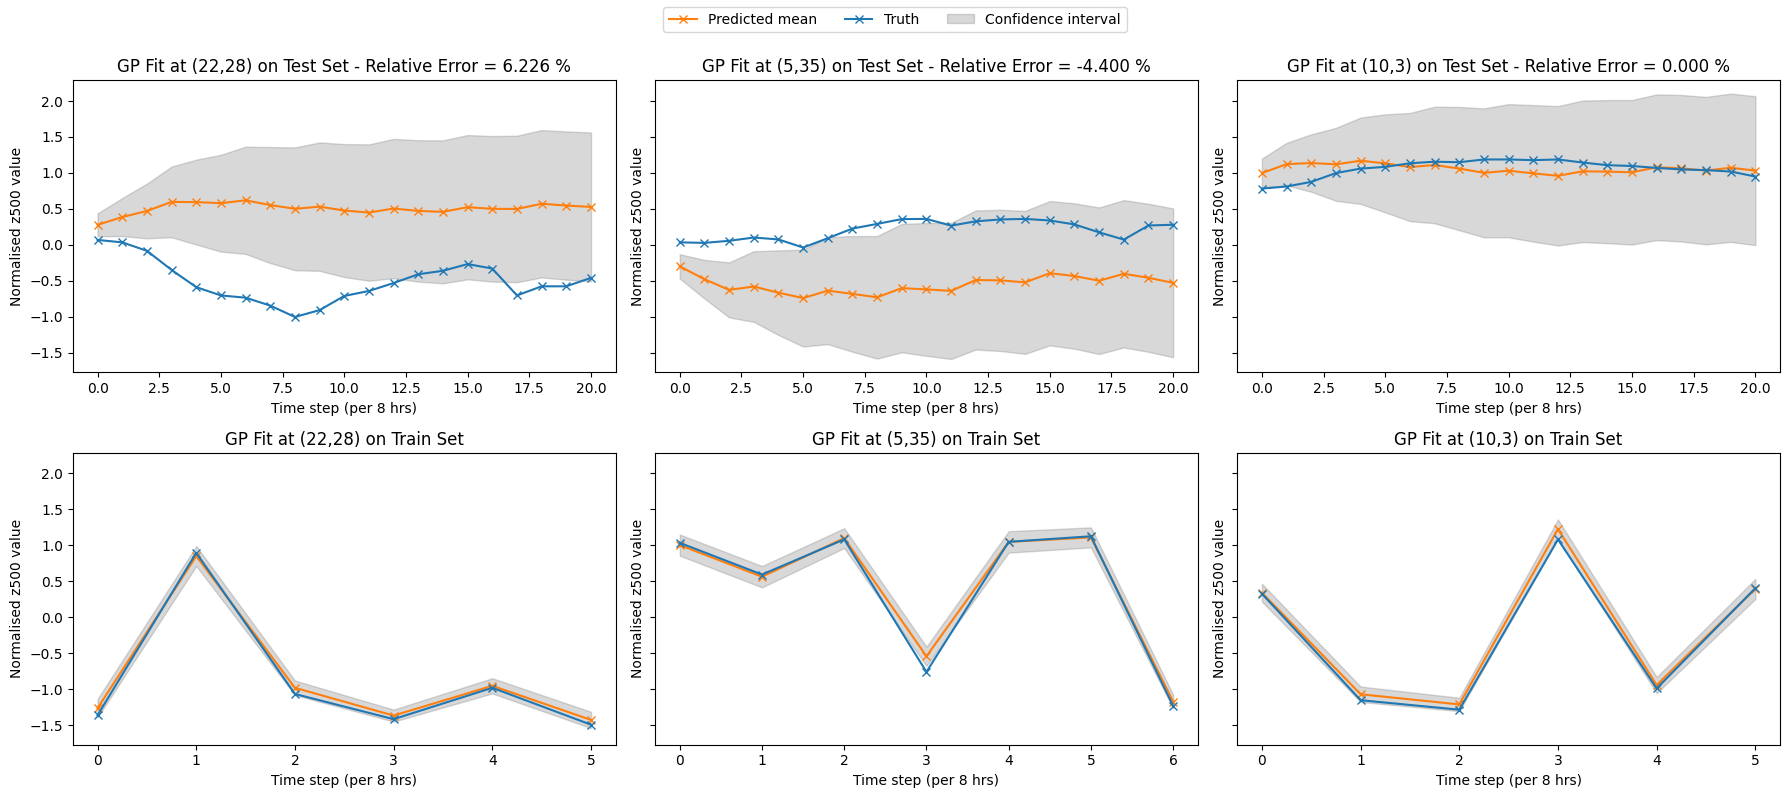

In [ ]:
# Create a 2x3 figure
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=False, sharey=True)

idx = [max_idx, min_idx, best_idx]
val = [max_err, min_err, best_err]

for i, p_idx in enumerate(idx):
    flat_idx = np.unravel_index(p_idx, relative_error_mean.shape)
    ax = axes[0, i]  

    pred_vals = Y_pred.reshape(-1)[p_idx::(nlat*nlon)]
    truth_vals = Y_test.reshape(-1)[p_idx::(nlat*nlon)]
    std_vals = Y_std.reshape(-1)[p_idx::(nlat*nlon)]

    ax.plot(pred_vals, marker='x', label='Predicted mean', color='tab:orange')
    ax.plot(truth_vals, marker='x', label='Truth', color='tab:blue')
    ax.fill_between(np.arange(len(pred_vals)),
                    pred_vals - 2 * std_vals,
                    pred_vals + 2 * std_vals,
                    alpha=0.3, color='tab:gray', label='Confidence interval')
    ax.set_xlabel(f"Time step (per {time_subsample} hrs)")
    ax.set_ylabel("Normalised z500 value")
    ax.set_title(f"GP Fit at ({int(flat_idx[0])},{int(flat_idx[1])}) on Test Set - Relative Error = {val[i]:.3f} %")

for i, p_idx in enumerate(idx):
    flat_idx = np.unravel_index(p_idx, relative_error_mean.shape)
    ax = axes[1, i]  

    pred_vals = train_mean.reshape(-1)[p_idx::(nlat*nlon)]
    truth_vals = Y_train.reshape(-1)[p_idx::(nlat*nlon)]
    std_vals = train_std.reshape(-1)[p_idx::(nlat*nlon)]

    ax.plot(pred_vals, marker='x', label='Predicted mean', color='tab:orange')
    ax.plot(truth_vals, marker='x', label='Truth', color='tab:blue')
    ax.fill_between(np.arange(len(pred_vals)),
                    pred_vals - 2 * std_vals,
                    pred_vals + 2 * std_vals,
                    alpha=0.3, color='tab:gray', label='Confidence interval')
    ax.set_xlabel(f"Time step (per {time_subsample} hrs)")
    ax.set_ylabel("Normalised z500 value")
    ax.set_title(f"GP Fit at ({int(flat_idx[0])},{int(flat_idx[1])}) on Train Set")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3)

plt.tight_layout(rect=[0, 0, 1, 0.95]) 
plt.show()

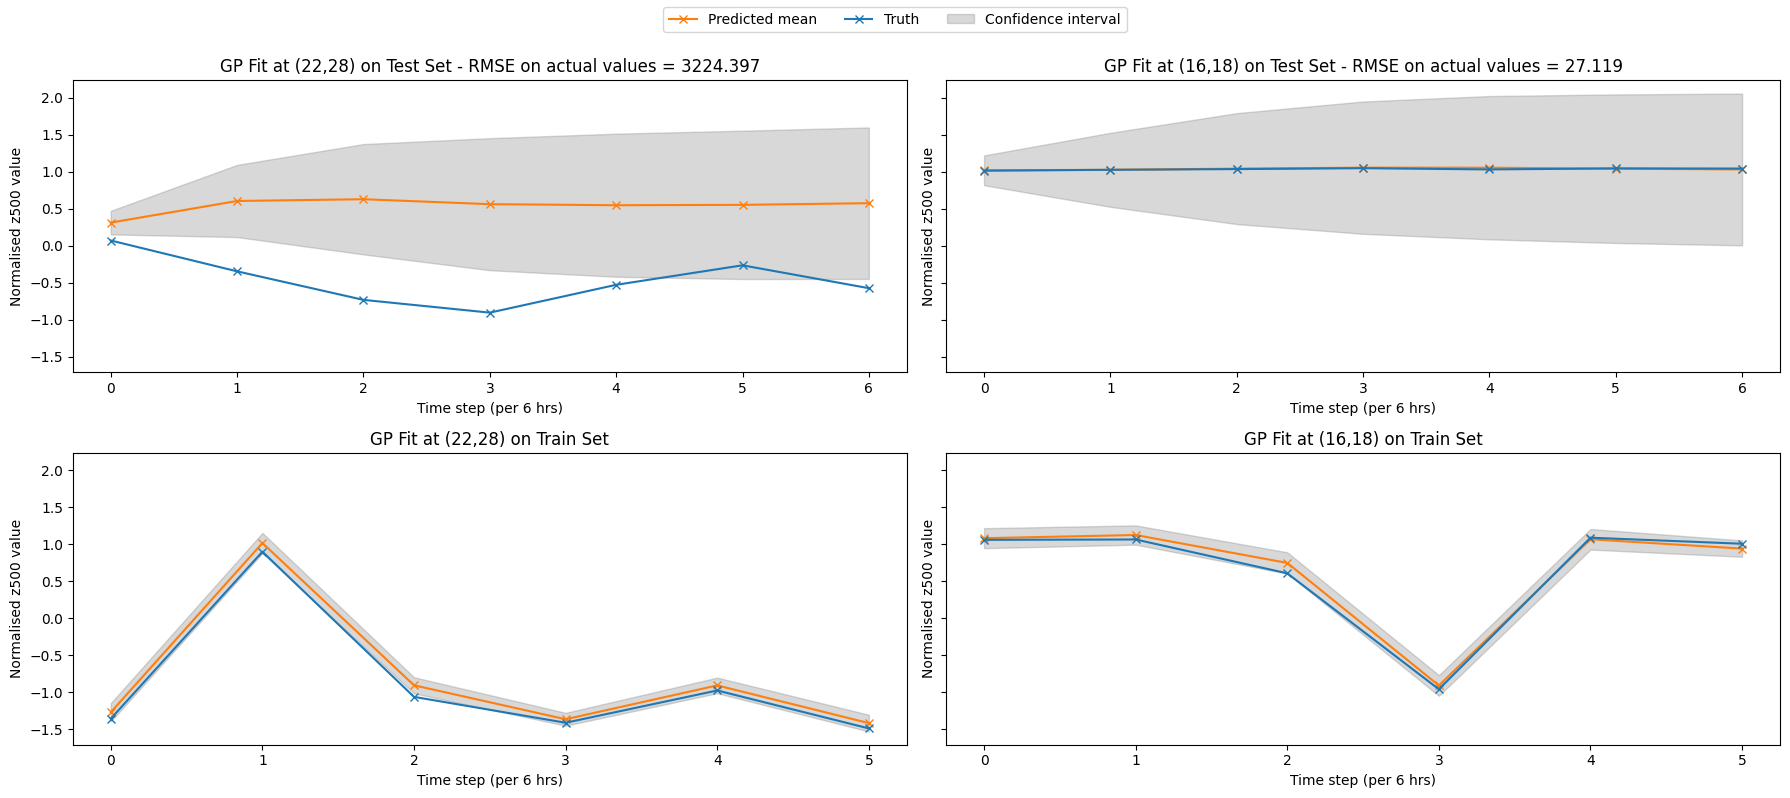

In [ ]:
# Create a 2x3 figure
fig, axes = plt.subplots(2, 2, figsize=(18, 8), sharex=False, sharey=True)

idx = [rmse_max_idx, rmse_min_idx]
val = [rmse_max_err, rmse_min_err]

for i, p_idx in enumerate(idx):
    flat_idx = np.unravel_index(p_idx, rmse_error_mean.shape)
    ax = axes[0, i]  

    pred_vals = Y_pred.reshape(-1)[p_idx::(nlat*nlon)]
    truth_vals = Y_test.reshape(-1)[p_idx::(nlat*nlon)]
    std_vals = Y_std.reshape(-1)[p_idx::(nlat*nlon)]

    ax.plot(pred_vals, marker='x', label='Predicted mean', color='tab:orange')
    ax.plot(truth_vals, marker='x', label='Truth', color='tab:blue')
    ax.fill_between(np.arange(len(pred_vals)),
                    pred_vals - 2 * std_vals,
                    pred_vals + 2 * std_vals,
                    alpha=0.3, color='tab:gray', label='Confidence interval')
    ax.set_xlabel(f"Time step (per {time_subsample} hrs)")
    ax.set_ylabel("Normalised z500 value")
    ax.set_title(f"GP Fit at ({int(flat_idx[0])},{int(flat_idx[1])}) on Test Set - RMSE on actual values = {val[i]:.3f}")

for i, p_idx in enumerate(idx):
    flat_idx = np.unravel_index(p_idx, rmse_error_mean.shape)
    ax = axes[1, i]  

    pred_vals = train_mean.reshape(-1)[p_idx::(nlat*nlon)]
    truth_vals = Y_train.reshape(-1)[p_idx::(nlat*nlon)]
    std_vals = train_std.reshape(-1)[p_idx::(nlat*nlon)]

    ax.plot(pred_vals, marker='x', label='Predicted mean', color='tab:orange')
    ax.plot(truth_vals, marker='x', label='Truth', color='tab:blue')
    ax.fill_between(np.arange(len(pred_vals)),
                    pred_vals - 2 * std_vals,
                    pred_vals + 2 * std_vals,
                    alpha=0.3, color='tab:gray', label='Confidence interval')
    ax.set_xlabel(f"Time step (per {time_subsample} hrs)")
    ax.set_ylabel("Normalised z500 value")
    ax.set_title(f"GP Fit at ({int(flat_idx[0])},{int(flat_idx[1])}) on Train Set")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3)

plt.tight_layout(rect=[0, 0, 1, 0.95]) 
plt.show()

In [ ]:
"""del model, likelihood, X_test, Y_test
torch.cuda.empty_cache()
gc.collect()"""

4035

Now train on the whole 2017 per montly

In [ ]:
"""lead_time = 24 # 1-day forecasting
space_subsample = 5 # Sub-sample every 5th point
time_subsample = 6 # Sub-sample every 8th hour

monthly_results = []  # For performance and hyperparams by month

# Loop over the months of 2017, training on one month and testing on the following month
for month in range(1, 13):
    if month < 12:
        train_month = f"2017-{month:02d}"
        test_month = f"2017-{month+1:02d}"
    else:
        # For December, train on 2017-12 and test on 2018-01.
        train_month = "2017-12"
        test_month = "2018-01"
    
    print(f"\nTraining on {train_month} and testing on {test_month}...")
    
    z_train = z500.sel(time=slice(train_month, train_month))['z']
    z_test = z500.sel(time=slice(test_month, test_month))['z']
    
    # Normalise the dataset
    data_mean = z_train.mean().load()
    data_std = z_train.std().load()
    data_train = (z_train - data_mean) / data_std
    data_test = (z_test - data_mean) / data_std
    
    model, likelihood, loss_history, X_test, Y_test, lat, lon = train_gp(lead_time, data_train, data_test, space_subsample, time_subsample)
    
    # Evaluate on test data.
    model.eval()
    likelihood.eval()
    with torch.no_grad():
        pred_dist = model(X_test)
        Y_pred = pred_dist.mean
        mse = torch.mean((Y_pred - Y_test) ** 2)
        rmse = torch.sqrt(mse).item()

    spatial_kernel = model.covar_module.kernels[0]
    time_sum_kernel = model.covar_module.kernels[1]
    periodic1 = time_sum_kernel.kernels[0]
    periodic2 = time_sum_kernel.kernels[1]
    #periodic3 = time_sum_kernel.kernels[2]
    
    monthly_results.append({
        "rmse": rmse,
        "mean": model.mean_module.constant.item(),
        "spatial_lengthscale": spatial_kernel.base_kernel.lengthscale.item(),
        "spatial_outputscale": spatial_kernel.outputscale.item(),
        "time_lengthscale_daily": periodic1.lengthscale.item(),
        "time_period_daily": periodic1.period_length.item(),
        "time_lengthscale_weekly": periodic2.lengthscale.item(),
        "time_period_weekly": periodic2.period_length.item(),
        #"time_lengthscale_monthly": periodic3.lengthscale.item() ,
        #"time_period_monthly": periodic3.period_length.item(),
    })
    
    print(f"RMSE on {test_month}: {rmse:.3f}")
    
    # Clean up: delete the model and clear the CUDA cache to release GPU memory.
    del model, likelihood, X_test, Y_test
    torch.cuda.empty_cache()
    gc.collect()"""


Training on 2017-01 and testing on 2017-02...
Processing Training Dataset
Combined coords info --> Shape: torch.Size([10920, 4]), Mem: 0.33 MB
Target info --> Shape: torch.Size([10920]), Mem: 0.04 MB
Processing Test Dataset
Combined coords info --> Shape: torch.Size([9828, 4]), Mem: 0.30 MB
Target info --> Shape: torch.Size([9828]), Mem: 0.04 MB
Starting Exact GP regression training on a single month:


Training Progress:   0%|          | 0/200 [00:00<?, ?epoch/s]

Current GPU memory allocated: 931.63 MB
Peak GPU memory allocated: 46426.66 MB
Training completed
Training time: 533.20s
RMSE on 2017-02: 0.353

Training on 2017-02 and testing on 2017-03...
Processing Training Dataset
Combined coords info --> Shape: torch.Size([9828, 4]), Mem: 0.30 MB
Target info --> Shape: torch.Size([9828]), Mem: 0.04 MB
Processing Test Dataset
Combined coords info --> Shape: torch.Size([10920, 4]), Mem: 0.33 MB
Target info --> Shape: torch.Size([10920]), Mem: 0.04 MB
Starting Exact GP regression training on a single month:


Training Progress:   0%|          | 0/200 [00:00<?, ?epoch/s]

Current GPU memory allocated: 2395.23 MB
Peak GPU memory allocated: 39243.01 MB
Training completed
Training time: 452.54s
RMSE on 2017-03: 0.311

Training on 2017-03 and testing on 2017-04...
Processing Training Dataset
Combined coords info --> Shape: torch.Size([10920, 4]), Mem: 0.33 MB
Target info --> Shape: torch.Size([10920]), Mem: 0.04 MB
Processing Test Dataset
Combined coords info --> Shape: torch.Size([10556, 4]), Mem: 0.32 MB
Target info --> Shape: torch.Size([10556]), Mem: 0.04 MB
Starting Exact GP regression training on a single month:


...

Current GPU memory allocated: 2691.09 MB
Peak GPU memory allocated: 48187.42 MB
Training completed
Training time: 542.92s
RMSE on 2017-11: 0.322

Training on 2017-11 and testing on 2017-12...
Processing Training Dataset
Combined coords info --> Shape: torch.Size([10556, 4]), Mem: 0.32 MB
Target info --> Shape: torch.Size([10556]), Mem: 0.04 MB
Processing Test Dataset
Combined coords info --> Shape: torch.Size([10920, 4]), Mem: 0.33 MB
Target info --> Shape: torch.Size([10920]), Mem: 0.04 MB
Starting Exact GP regression training on a single month:


Training Progress:   0%|          | 0/200 [00:00<?, ?epoch/s]

Current GPU memory allocated: 2631.33 MB
Peak GPU memory allocated: 45139.33 MB
Training completed
Training time: 509.23s
RMSE on 2017-12: 0.356

Training on 2017-12 and testing on 2018-01...
Processing Training Dataset
Combined coords info --> Shape: torch.Size([10920, 4]), Mem: 0.33 MB
Target info --> Shape: torch.Size([10920]), Mem: 0.04 MB
Processing Test Dataset
Combined coords info --> Shape: torch.Size([10920, 4]), Mem: 0.33 MB
Target info --> Shape: torch.Size([10920]), Mem: 0.04 MB
Starting Exact GP regression training on a single month:


Training Progress:   0%|          | 0/200 [00:00<?, ?epoch/s]

Current GPU memory allocated: 2691.11 MB
Peak GPU memory allocated: 48187.44 MB
Training completed
Training time: 550.15s
RMSE on 2018-01: 0.285


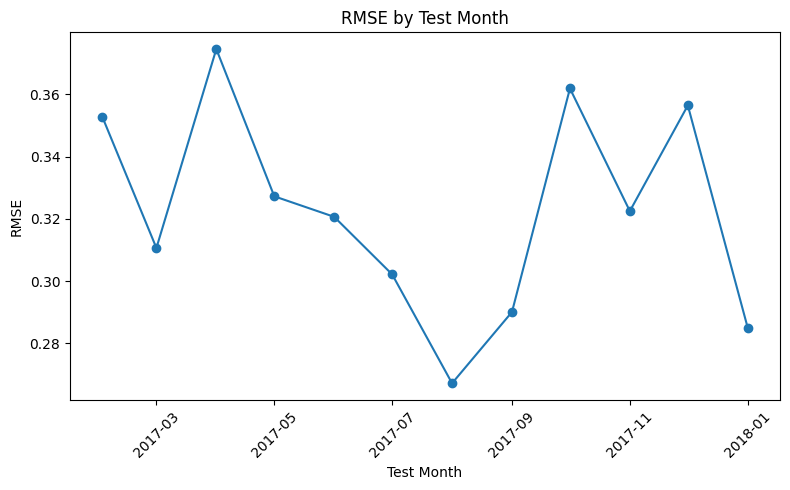

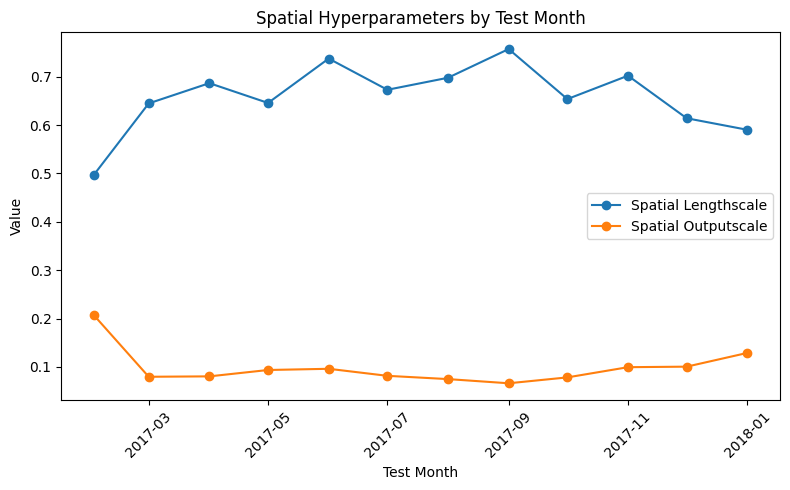

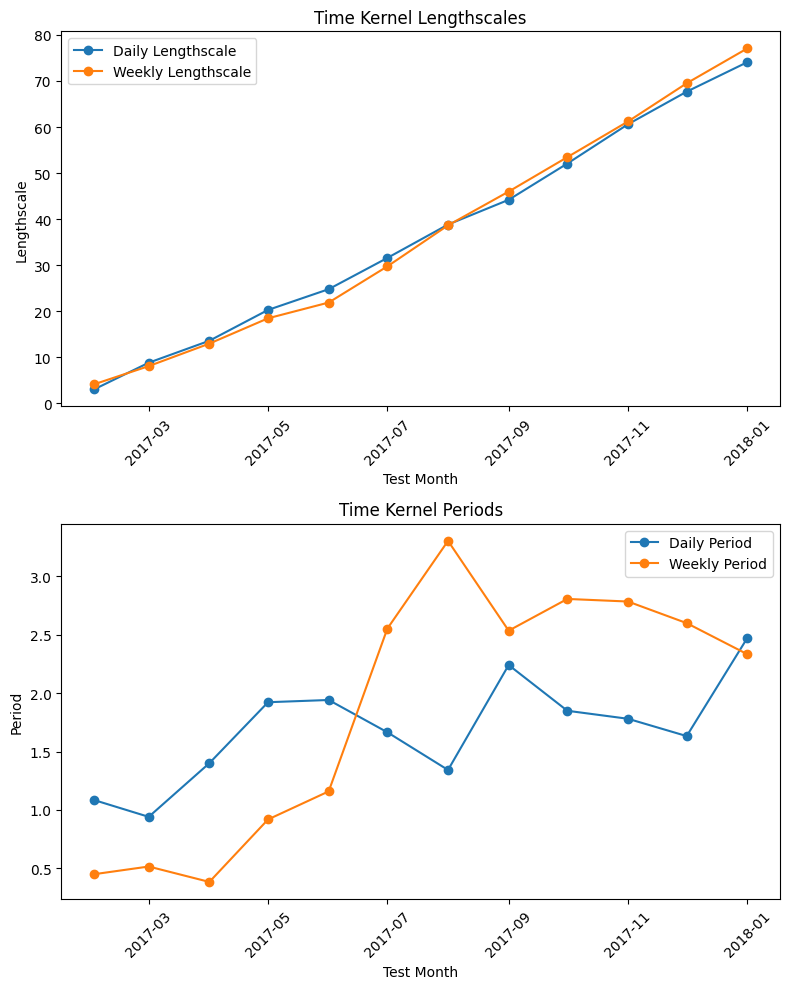

In [ ]:
"""import pandas as pd

# Convert the monthly_results list into a DataFrame.
df = pd.DataFrame(monthly_results)

# Create test month labels assuming the loop order:
# For months 1 to 11, the test month is "2017-{month+1:02d}", and for month 12 it's "2018-01".
test_months = [f"2017-{month+1:02d}" if month < 12 else "2018-01" for month in range(1, 13)]
df["test_month"] = pd.to_datetime(test_months, format="%Y-%m")


# Plot RMSE by Test Month
plt.figure(figsize=(8, 5))
plt.plot(df["test_month"], df["rmse"], marker="o", linestyle="-")
plt.xlabel("Test Month")
plt.ylabel("RMSE")
plt.title("RMSE by Test Month")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot Spatial Hyperparameters
plt.figure(figsize=(8, 5))
plt.plot(df["test_month"], df["spatial_lengthscale"], marker="o", linestyle="-", label="Spatial Lengthscale")
plt.plot(df["test_month"], df["spatial_outputscale"], marker="o", linestyle="-", label="Spatial Outputscale")
plt.xlabel("Test Month")
plt.ylabel("Value")
plt.title("Spatial Hyperparameters by Test Month")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot Time Hyperparameters in two subplots:
# One for lengthscales and one for periods.
fig, axs = plt.subplots(2, 1, figsize=(8, 10))

# Plot time lengthscales for daily, weekly, and monthly kernels.
axs[0].plot(df["test_month"], df["time_lengthscale_daily"], marker="o", linestyle="-", label="Daily Lengthscale")
axs[0].plot(df["test_month"], df["time_lengthscale_weekly"], marker="o", linestyle="-", label="Weekly Lengthscale")
# axs[0].plot(df["test_month"], df["time_lengthscale_monthly"], marker="o", linestyle="-", label="Monthly Lengthscale")
axs[0].set_title("Time Kernel Lengthscales")
axs[0].set_xlabel("Test Month")
axs[0].set_ylabel("Lengthscale")
axs[0].legend()
axs[0].tick_params(axis="x", rotation=45)

# Plot time periods for daily, weekly, and monthly kernels.
axs[1].plot(df["test_month"], df["time_period_daily"], marker="o", linestyle="-", label="Daily Period")
axs[1].plot(df["test_month"], df["time_period_weekly"], marker="o", linestyle="-", label="Weekly Period")
# axs[1].plot(df["test_month"], df["time_period_monthly"], marker="o", linestyle="-", label="Monthly Period")
axs[1].set_title("Time Kernel Periods")
axs[1].set_xlabel("Test Month")
axs[1].set_ylabel("Period")
axs[1].legend()
axs[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()"""